# deRSE Poster 

In [1]:
import pandas as pd
import numpy as np
import datetime

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, cut_tree, dendrogram
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

current_date_info = datetime.datetime.now().strftime(
    "%Y-%m-%d"
)
print(current_date_info)

2025-04-22


In [2]:
# load repos data:
dataset_repo_stats = pd.read_csv("../../data/summarised_dataset_repos_stats_2025-02-18.csv") # relevant, licensed repo stats summaries  
dataset_repo_languages = pd.read_csv("../../data/summarised_dataset_repos_language_stats_2025-02-18.csv") # language details derived from above df

preprocess_dataset = pd.read_csv("../../data/pre-processing_dataset_x45repos_x791project-individuals_2025-02-18.csv") # before any encoding, standardsation, etc

# load analysis datasets (enerated in RSE_Personas-Sprint4.ipynb.)
clustering_dataset = pd.read_csv("../../data/clustering_data_used_for_analysis_x45-repos_x791project-individuals_2025-02-18.csv") # standardised, encoded, clustering dataset
analysis_dataset = pd.read_csv("../../data/repo_interactions_dataset_used_for_analysis_x45-repos_x791project-individuals_2025-02-18.csv") # main dataset. 

In [14]:
dataset_repo_stats.columns

Index(['repo_name', 'initial_HTTP_code', 'issues_enabled', 'repo_license',
       'repo_visibility', 'repo_is_fork', 'devs', 'repo_language',
       'total_commits_last_year', 'has_PRs', 'last_PR_update', 'open_tickets',
       'closed_tickets', 'repo_age_days', 'n_commits_main_branch',
       'repo_stats_sanitised', 'licensed_to_use'],
      dtype='object')

In [19]:
deRSE_sanitised = list(analysis_dataset.repo_name_sanitised.unique())

In [27]:
actual_dataset_repo_stats = dataset_repo_stats[dataset_repo_stats["repo_stats_sanitised"].isin(deRSE_sanitised)].reset_index()
actual_dataset_repo_stats

,index,repo_name,initial_HTTP_code,issues_enabled,repo_license,repo_visibility,repo_is_fork,devs,repo_language,total_commits_last_year,has_PRs,last_PR_update,open_tickets,closed_tickets,repo_age_days,n_commits_main_branch,repo_stats_sanitised,licensed_to_use
0,0,numenta/htmresearch-core,200,True,AGPL-3.0,True,False,50,"['C++', 'CMake', 'Shell', 'Python', 'PowerShel...",0,True,2019-07-26 21:18:24+00:00,0,86,2982,3622,numenta-htmresearch-core,True
1,1,Continvvm/continuum,200,True,MIT,True,False,20,"['Python', 'Makefile']",0,True,2025-02-05 08:40:14+00:00,32,257,1771,1142,Continvvm-continuum,True
2,3,kellykochanski/rescal-snow,200,True,GPL-3.0,True,False,35,"['C', 'Python', 'Shell', 'CMake', 'TeX', 'C++']",0,True,2019-10-24 18:28:14+00:00,4,49,2453,328,kellykochanski-rescal-snow,True
3,8,PPMstar/PyPPM,200,True,BSD-3-Clause,True,False,19,"['Python', 'HTML', 'Jupyter Notebook']",3,True,2023-07-27 22:33:10+00:00,3,48,3035,409,PPMstar-PyPPM,True
4,9,Qiskit/qiskit-experiments,200,True,Apache-2.0,True,False,49,['Python'],43,True,2025-02-11 23:20:39+00:00,174,1331,1451,752,Qiskit-qiskit-experiments,True
5,11,sgoldenlab/simba,200,True,GPL-3.0,True,False,13,"['Python', 'CSS', 'Jupyter Notebook', 'HTML']",636,True,2024-04-25 16:25:17+00:00,153,250,1989,4600,sgoldenlab-simba,True
6,12,EMMC-ASBL/otelib,200,True,MIT,True,False,14,['Python'],66,True,2025-02-10 21:58:30+00:00,15,253,1130,238,EMMC-ASBL-otelib,True
7,15,choderalab/assaytools,200,True,LGPL-2.1,True,False,17,"['Python', 'Shell']",0,True,2021-09-20 20:39:54+00:00,56,90,3681,553,choderalab-assaytools,True
8,18,ess-dmsc/kafka-to-nexus,200,True,BSD-2-Clause,True,False,35,"['C++', 'CMake', 'Python', 'Shell', 'Dockerfile']",153,True,2025-01-17 13:31:24+00:00,2,720,2928,5939,ess-dmsc-kafka-to-nexus,True
9,19,pearsonlab/improv,200,True,MIT,True,False,23,"['Python', 'CSS']",3,True,2025-02-14 21:16:08+00:00,19,181,2346,1204,pearsonlab-improv,True


In [28]:
from utilities.repo_names_write_out import RepoNamesListCreator

reponameslistcreator = RepoNamesListCreator(logger=None, in_notebook=True)

reponameslistcreator.repo_names_write_out(namelist= list(actual_dataset_repo_stats.repo_name.unique()), repo_name_filename="deRSE-sample-repo-names-list", write_location="../../data/")
list(actual_dataset_repo_stats.repo_name.unique())

INFO:Wrote out 45 records to file deRSE-sample-repo-names-list_2025-04-22_x45.txt.


['numenta/htmresearch-core',
 'Continvvm/continuum',
 'kellykochanski/rescal-snow',
 'PPMstar/PyPPM',
 'Qiskit/qiskit-experiments',
 'sgoldenlab/simba',
 'EMMC-ASBL/otelib',
 'choderalab/assaytools',
 'ess-dmsc/kafka-to-nexus',
 'pearsonlab/improv',
 'explorable-viz/fluid',
 'theosanderson/taxonium',
 'astropy/extension-helpers',
 'carbonplan/cmip6-downscaling',
 'dacapobench/dacapobench',
 'shivareddyiirs/QRealTime',
 'korpling/ANNIS',
 'astropy/sphinx-automodapi',
 'ecds/readux',
 'bccp/nbodykit',
 'jries/SMAP',
 'smarr/SOMns',
 'monarch-initiative/embiggen',
 'WorldVistA/VistA',
 'pachterlab/gget',
 'HERA-Team/librarian',
 'AD-EYE/AD-EYE_Core',
 'PreibischLab/RS-FISH',
 'ContextLab/CDL-bibliography',
 'BrainCog-X/Brain-Cog',
 'NervanaSystems/coach',
 'CarperAI/cheese',
 'PecanProject/bety',
 'biothings/discovery-app',
 'NGSolve/netgen',
 'plantinformatics/pretzel',
 'mac-theobio/McMasterPandemic',
 'mrirecon/bart',
 'OnroerendErfgoed/language-tags',
 'DGtal-team/DGtalTools',
 'palas

['numenta/htmresearch-core',
 'Continvvm/continuum',
 'ohbm/hackathon2020',
 'kellykochanski/rescal-snow',
 'gbif/gbif-api',
 'mariuslam/PAPER2_FATES',
 'coq-tactician/coq-tactician',
 'oaworks/website',
 'PPMstar/PyPPM',
 'Qiskit/qiskit-experiments',
 'JuliaParallel/MPI.jl',
 'sgoldenlab/simba',
 'EMMC-ASBL/otelib',
 'Uko/Renraku',
 'BiologicalRecordsCentre/sparta',
 'choderalab/assaytools',
 'SciGraph/SciGraph',
 'microbiome/miaSim',
 'ess-dmsc/kafka-to-nexus',
 'pearsonlab/improv',
 'SCBI-ForestGEO/2023census',
 'Dong-Hyeon-Yu/optme-evm',
 'explorable-viz/fluid',
 'theosanderson/taxonium',
 'astropy/extension-helpers',
 'carbonplan/cmip6-downscaling',
 'dacapobench/dacapobench',
 'shivareddyiirs/QRealTime',
 'korpling/ANNIS',
 'astropy/sphinx-automodapi',
 'frictionlessdata/datapackage',
 'ecds/readux',
 'bccp/nbodykit',
 'jries/SMAP',
 'smarr/SOMns',
 'monarch-initiative/embiggen',
 'WorldVistA/VistA',
 'pachterlab/gget',
 'HERA-Team/librarian',
 'AD-EYE/AD-EYE_Core',
 'PreibischLa

In [ ]:
list(preprocess_dataset.repo_name.unique())

In [322]:
# plotting details: 
label_color_dict = {0:'#D50032', 1:'#1D2A3D', 2:'#FDBC42'} # universityred, epccnavy, dandelion, 

## DATASET CONTEXT

In [211]:
print(f"Dataset contains {analysis_dataset.groupby('repo_name').ngroups} unique repositories") # 102 repositories  
print(f"Dataset contains {len(analysis_dataset.groupby(['repo_name', 'gh_username']))} project-individuals") # 2479 project

Dataset contains 45 unique repositories
Dataset contains 791 project-individuals


? What size are the repositories?  

Using 'number of unique committers to the repository' as a rough guide to size (though this doesn't take account of gaps in presence or how many people were active at once).  

 - we've excluded repositories <=10 unique committers  
 - we've excluded repositories with > 130 unique committers (>2 StandardDeviations from mean) 
 - we've excluded repositories which are forks of another repository  
 - we've excluded all repositories which do not include 2 of the main RS programming languages: "Python" (widely used) and "C++" (workhorse RS language) 

In [212]:
dataset_repo_stats.columns

Index(['repo_name', 'initial_HTTP_code', 'issues_enabled', 'repo_license',
       'repo_visibility', 'repo_is_fork', 'devs', 'repo_language',
       'total_commits_last_year', 'has_PRs', 'last_PR_update', 'open_tickets',
       'closed_tickets', 'repo_age_days', 'n_commits_main_branch',
       'repo_stats_sanitised', 'licensed_to_use'],
      dtype='object')

In [213]:
dataset_repo_stats.repo_is_fork.value_counts()

repo_is_fork
False    67
Name: count, dtype: int64

In [214]:
# REMOVE FORKS!!
# repo_is_fork
# False    67
# True     35

? How many repositories are code-only?  

? How many repositories used issue tickets (open / closed)  

? How many repositories assign tickets?  

? How many repositories create PRs?  

In [215]:
#analysis_dataset.columns

grouped_by_repo = analysis_dataset.groupby("repo_name")

In [217]:
commit_only_users = analysis_dataset.query(
    "pc_commit_created > 0 and pc_pull_request_created == 0 and pc_issue_created == 0 and pc_issue_closed == 0 and pc_issues_assigned_of_assigned == 0"
)
commit_only_users_repos = commit_only_users.groupby("repo_name").ngroups

print(f"There are {len(commit_only_users)} users who only contribute commits to {commit_only_users_repos} unique repositories.")

There are 482 users who only contribute commits to 41 unique repositories.


<Axes: xlabel='n_of_commit_creators', ylabel='Count'>

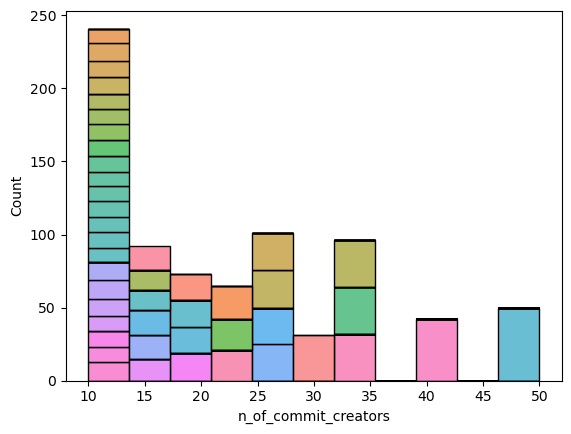

In [307]:
sns.histplot(data=analysis_dataset, x="n_of_commit_creators", hue="repo_name",legend=False, multiple="stack")

<Axes: xlabel='None', ylabel='Count'>

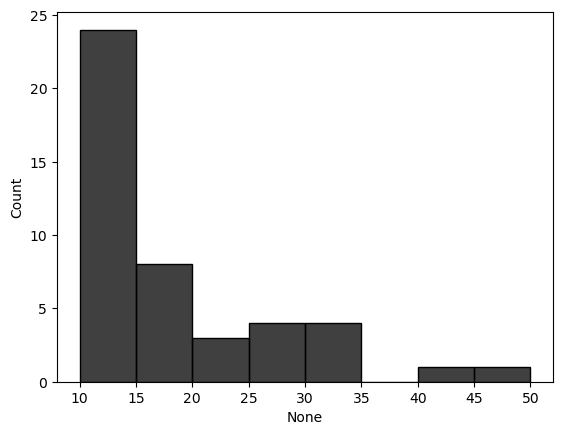

In [310]:
sns.histplot(x=analysis_dataset.groupby("repo_name").size(), color='black')

Counts of n_of_commit_creators in repos; lines representing 1SD (9.25), 1.5SD (13.88) and 2 (18.51)


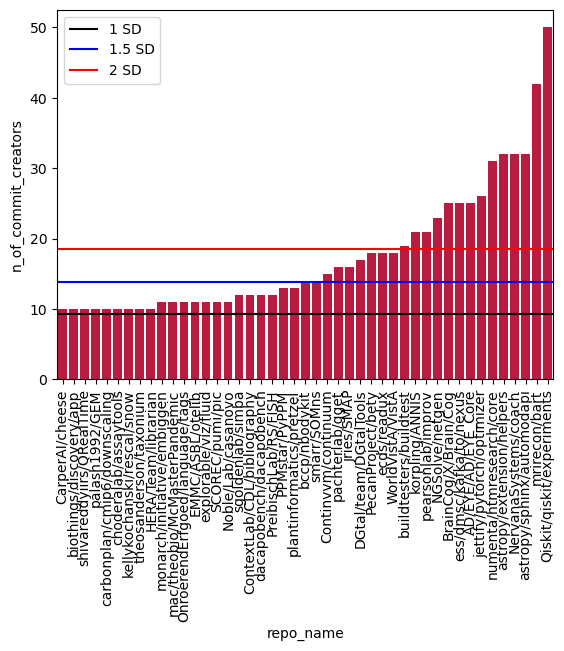

In [316]:
# MORE STATISTICALLY LEGIT WAY OF FINDING UPPER MAXIMUM 'REPO SIZE'

# Counts of n_of_commit_creators in repos
ax = sns.barplot(
    data=analysis_dataset.sort_values(by="n_of_commit_creators", axis=0), 
    x="repo_name", 
    y="n_of_commit_creators", 
)
ax.axhline(y=analysis_dataset.groupby("repo_name").size().std(), color="black").set_label("1 SD") ## THIS IS 1 Std Deviation 
ax.axhline(y=analysis_dataset.groupby("repo_name").size().std()*1.5, color="blue").set_label("1.5 SD") 
ax.axhline(y=analysis_dataset.groupby("repo_name").size().std()*2, color="red").set_label("2 SD") 
ax.legend()  # adds the line legend in 

ax.tick_params(axis='x', which='both', rotation=90)
print(f'Counts of n_of_commit_creators in repos; lines representing 1SD ({round(analysis_dataset.groupby("repo_name").size().std(), 2)}), 1.5SD ({round(analysis_dataset.groupby("repo_name").size().std()*1.5, 2)}) and 2 ({round(analysis_dataset.groupby("repo_name").size().std()*2, 2)})')


In [231]:
analysis_dataset.cluster_labels.value_counts()

cluster_labels
0    714
2     59
1     18
Name: count, dtype: int64

In [232]:
59+18

77

In [219]:
all_types_users = analysis_dataset.query(
    "pc_commit_created > 0 and pc_pull_request_created > 0 and pc_issue_created > 0 and pc_issue_closed > 0 and pc_issues_assigned_of_assigned > 0"
)
all_types_users_repos = all_types_users.groupby("repo_name").ngroups

print(f"There are {len(all_types_users)} users who contribute to ALL UIT types from {all_types_users_repos} unique repositories.")

There are 18 users who contribute to ALL UIT types from 9 unique repositories.


In [220]:
analysis_dataset.breadth_interactions.value_counts()

breadth_interactions
1    482
2    143
3     88
4     60
5     18
Name: count, dtype: int64

In [222]:
analysis_dataset.breadth_interactions.value_counts(normalize=True)*100

breadth_interactions
1    60.935525
2    18.078382
3    11.125158
4     7.585335
5     2.275601
Name: proportion, dtype: float64

In [223]:
clustering_data_labelled

,cluster_labels,breadth_interactions,pc_commit_created,pc_issue_created,pc_issue_closed,pc_issues_assigned_of_assigned,pc_pull_request_created,pc_DC,pc_sum_n_interactions,pc_interaction_days,interaction_days,interaction_period_days,pc_created-closed_issues,sum_n_interactions,mean_n_interactions_per_interaction_day,interactions_by_user_encoded
0,0,1,0.184502,0.000000,0.000000,0.000000,0.000000,0.036900,0.180505,0.117647,-0.318273,-0.619259,0.222614,-0.218512,0.506692,0
1,0,1,1.845018,0.000000,0.000000,0.000000,0.000000,0.369004,1.805054,2.705882,-0.138536,1.462009,0.222614,-0.177064,-0.569965,0
2,0,1,1.537515,0.000000,0.000000,0.000000,0.000000,0.307503,1.504212,1.411765,-0.228405,-0.099490,0.222614,-0.184740,-0.075347,0
3,0,1,0.184502,0.000000,0.000000,0.000000,0.000000,0.036900,0.180505,0.117647,-0.318273,-0.619259,0.222614,-0.218512,0.506692,0
4,0,3,0.184502,4.761905,7.142857,0.000000,0.000000,2.417853,0.300842,0.352941,-0.301934,-0.459161,-0.370377,-0.215442,-0.339910,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
786,0,4,2.092640,3.066038,0.996264,1.856764,0.000000,1.602341,2.086614,3.292806,0.204598,-0.078656,0.141913,0.102327,0.672756,6
787,0,2,0.035269,1.533019,0.000000,0.000000,0.000000,0.313658,0.157480,0.607903,-0.228405,1.079310,0.223895,-0.198556,-0.551561,3
788,0,1,0.023513,0.000000,0.000000,0.000000,0.000000,0.004703,0.019685,0.101317,-0.310104,-0.617066,0.222614,-0.220047,-0.763211,0
789,1,5,83.588055,53.066038,77.085928,68.435013,66.666667,69.768340,80.521654,60.739615,9.469221,5.625639,-6.175561,12.335648,2.934231,9


In [ ]:
analysis_dataset.groupby(["cluster_labels"]).repo_name.nunique()

In [ ]:
analysis_dataset.columns

In [228]:
devs_per_cluster.groupby("cluster_labels")['n_devs'].describe()

,count,mean,std,min,25%,50%,75%,max
cluster_labels,,,,,,,,
0,45.0,15.866667,9.382285,8.0,9.0,12.0,20.0,50.0
1,17.0,1.058824,0.242536,1.0,1.0,1.0,1.0,2.0
2,33.0,1.787879,0.780928,1.0,1.0,2.0,2.0,4.0


In [229]:
devs_per_cluster.groupby("cluster_labels")['n_devs'].count()[1]

17

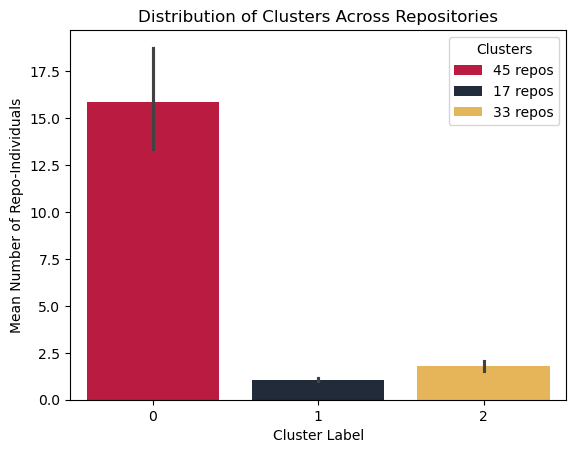

In [230]:
devs_per_cluster = analysis_dataset.groupby(["repo_name", "cluster_labels"])["gh_username"].count().reset_index(name="n_devs")
devs_per_cluster

cl0 = f'{devs_per_cluster.groupby("cluster_labels")["n_devs"].count()[0]} repos'
cl1 = f'{devs_per_cluster.groupby("cluster_labels")["n_devs"].count()[1]} repos'
cl2 = f'{devs_per_cluster.groupby("cluster_labels")["n_devs"].count()[2]} repos'

labels = [cl0, cl1, cl2]

g = sns.barplot(
    data=devs_per_cluster, 
    x="cluster_labels", 
    y="n_devs", 
    hue="cluster_labels",
    estimator="mean", 
    palette=label_color_dict, 
    legend="full",
)
g.set_title("Distribution of Clusters Across Repositories")
g.set_xlabel("Cluster Label")
g.set_ylabel("Mean Number of Repo-Individuals")
h, l = g.get_legend_handles_labels()
g.legend(h, labels, title="Clusters", loc="upper right")

#plt.legend(title="Clusters", loc='upper right', labels)
plt.savefig(f"../../images/cluster_repo_distribution_{current_date_info}.png") 
plt.show(g)

In [293]:
devs_per_cluster.groupby("repo_name")["cluster_labels"].unique().reset_index(name="combos")
devs_per_cluster

,repo_name,cluster_labels,n_devs
0,AD/EYE/AD/EYE_Core,0,24
1,AD/EYE/AD/EYE_Core,2,1
2,BrainCog/X/Brain/Cog,0,24
3,BrainCog/X/Brain/Cog,2,1
4,CarperAI/cheese,0,8
...,...,...,...
90,shivareddyiirs/QRealTime,1,1
91,smarr/SOMns,0,13
92,smarr/SOMns,1,1
93,theosanderson/taxonium,0,9


In [275]:
clusters_per_repo.groupby("n_clusters").count()

,repo_name
n_clusters,
1,1
2,38
3,6


In [297]:
(clusters_per_repo.groupby("n_clusters").count()/grouped_by_repo.ngroups)*100

,repo_name
n_clusters,
1,2.222222
2,84.444444
3,13.333333


In [333]:
clusters_per_repo

,repo_name,n_clusters
0,AD/EYE/AD/EYE_Core,2
1,BrainCog/X/Brain/Cog,2
2,CarperAI/cheese,3
3,ContextLab/CDL/bibliography,2
4,Continvvm/continuum,3
5,DGtal/team/DGtalTools,2
6,EMMC/ASBL/otelib,2
7,HERA/Team/librarian,2
8,NGSolve/netgen,2
9,NervanaSystems/coach,2


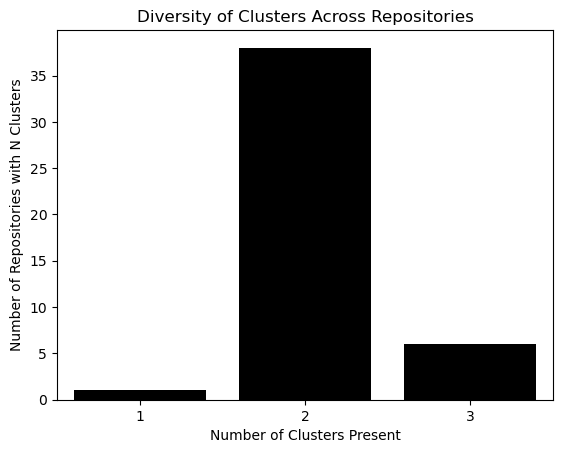

In [248]:
clusters_per_repo = devs_per_cluster.groupby("repo_name")["cluster_labels"].nunique().reset_index(name="n_clusters")
clusters_per_repo

clusters_per_repo.n_clusters.mean()

g = sns.countplot(
    data=clusters_per_repo, 
    x="n_clusters",
    color="black"
    #hue="cluster_labels",
    #palette=label_color_dict, 
)
g.set_title("Diversity of Clusters Across Repositories")
g.set_xlabel("Number of Clusters Present")
g.set_ylabel("Number of Repositories with N Clusters")
# h, l = g.get_legend_handles_labels()
# g.legend(h, labels, title="Clusters", loc="upper right")
# #plt.legend(title="Clusters", loc='upper right', labels)
plt.savefig(f"../../images/n-clusters-present-per-repo_{current_date_info}.png") 
plt.show(g)

# labels = [cl0, cl1, cl2]

# g = sns.barplot(
#     data=devs_per_cluster, 
#     x="cluster_labels", 
#     y="n_devs", 
#     hue="cluster_labels",
#     estimator="mean", 
#     palette=label_color_dict, 
#     legend="full",
# )
# g.set_title("Distribution of Clusters Across Repositories")
# g.set_xlabel("Cluster Label")
# g.set_ylabel("Mean Number of Repo-Individuals")
# h, l = g.get_legend_handles_labels()
# g.legend(h, labels, title="Clusters", loc="upper right")

# #plt.legend(title="Clusters", loc='upper right', labels)
# plt.savefig(f"../../images/cluster_repo_distribution_{current_date_info}.png") 
# plt.show(g)

In [239]:
clusters_per_repo

,repo_name,cluster_labels
0,AD/EYE/AD/EYE_Core,2
1,BrainCog/X/Brain/Cog,2
2,CarperAI/cheese,3
3,ContextLab/CDL/bibliography,2
4,Continvvm/continuum,3
5,DGtal/team/DGtalTools,2
6,EMMC/ASBL/otelib,2
7,HERA/Team/librarian,2
8,NGSolve/netgen,2
9,NervanaSystems/coach,2


In [ ]:
#sns.catplot(data=analysis_dataset, x="repo_name", hue="cluster_labels", kind="count", multiple='stack')

#### Clustering 

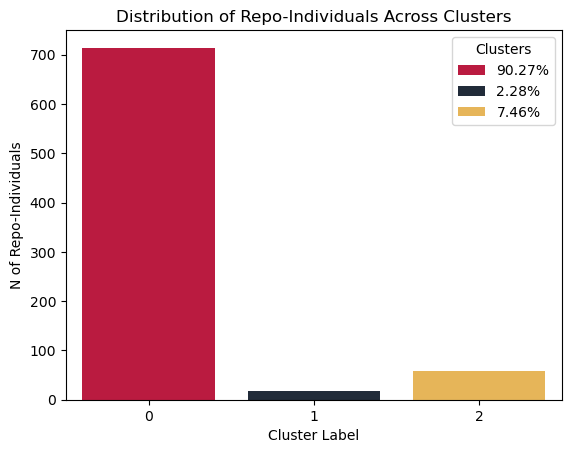

In [227]:
cl0 = round((analysis_dataset.cluster_labels.value_counts(normalize=True)[0]*100), 2)
cl1 = round((analysis_dataset.cluster_labels.value_counts(normalize=True)[1]*100), 2)
cl2 = round((analysis_dataset.cluster_labels.value_counts(normalize=True)[2]*100), 2)

# how are the users distributed across clusters: what size are the clusters? 
g = sns.countplot(
    data=analysis_dataset, 
    x="cluster_labels", 
    hue="cluster_labels", 
    stat="count", 
    palette=label_color_dict, 
)
#g.tick_params(axis='x', which='both', rotation=70)
g.set_title("Distribution of Repo-Individuals Across Clusters")
g.set_xlabel("Cluster Label")
g.set_ylabel("N of Repo-Individuals")
plt.legend(title="Clusters", loc='upper right', labels=[f"{cl0}%", f"{cl1}%", f"{cl2}%"])
plt.savefig(f"../../images/cluster_distribution_{current_date_info}.png") 
plt.show(g)

## BREADTH

In [ ]:
# ax = sns.boxplot(x='Day', y='Count', data=df)
# ax.set_title('lalala')
# ax.set_ylabel('lololo')

In [ ]:

# how are the users distributed across clusters: what size are the clusters? 
g = sns.countplot(
    data=analysis_dataset, 
    x="breadth_interactions", 
    hue="cluster_labels", 
    stat="count", 
    palette=label_color_dict, 
)
#g.tick_params(axis='x', which='both', rotation=70)
g.set_title("Distribution of Repo-Individuals by UIT")
g.set_xlabel("N of Unique Interaction Types (UIT)")
plt.legend(title="Clusters", loc='upper right',) #labels=[f"{cl0}%", f"{cl1}%", f"{cl2}%"])
plt.savefig(f"../../images/UIT_distribution_{current_date_info}.png") 
plt.show(g)

In [ ]:
import numpy as np
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

variable = "pc_commit_created"
df = analysis_dataset

# One-Way ANOVA: 
anova = f_oneway(
    df.groupby("cluster_labels")[variable].get_group(0),
    df.groupby("cluster_labels")[variable].get_group(1),
    df.groupby("cluster_labels")[variable].get_group(2),
)
    
print(f"{anova}")


# perform Tukey's test
tukey = pairwise_tukeyhsd(endog=df[variable],
                          groups=df['cluster_labels'],
                          alpha=0.05)

#display results
print(tukey)

print(f"For {variable}, anova result p-value is {anova.pvalue}; groups are significantly different = {anova.pvalue < 0.05}")
print(f"For {variable}, Tukey HSD test result p-value is {tukey.pvalues}; groups are significantly different = {tukey.reject == True}")



In [ ]:
import numpy as np
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

variable = "pc_pull_request_created"
df = analysis_dataset

# One-Way ANOVA: 
anova = f_oneway(
    df.groupby("cluster_labels")[variable].get_group(0),
    df.groupby("cluster_labels")[variable].get_group(1),
    df.groupby("cluster_labels")[variable].get_group(2),
)
    
print(f"{anova}")


# perform Tukey's test
tukey = pairwise_tukeyhsd(endog=df[variable],
                          groups=df['cluster_labels'],
                          alpha=0.05)

#display results
print(tukey)

print(f"For {variable}, anova result p-value is {anova.pvalue}; groups are significantly different = {anova.pvalue < 0.05}")
print(f"For {variable}, Tukey HSD test result p-value is {tukey.pvalues}; groups are significantly different = {tukey.reject == True}")


In [ ]:
df.groupby("cluster_labels")['pc_pull_request_created'].mean()

## DEPTH

In [ ]:
analysis_dataset.columns

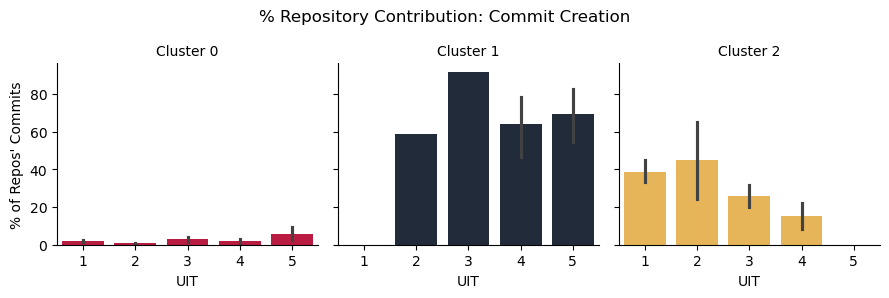

In [323]:

# how are the users distributed across clusters: what size are the clusters? 
g = sns.FacetGrid(data=analysis_dataset, sharey=True, col="cluster_labels",)
g.map_dataframe(sns.barplot,
    x="breadth_interactions", 
    y="pc_commit_created",
    hue="cluster_labels", 
    #binwidth=1,
    estimator="mean",
    palette=label_color_dict, 
)
g.set_axis_labels("")
g.set_titles("Cluster {col_name}")
g.figure.subplots_adjust(top=0.80)
g.figure.suptitle("% Repository Contribution: Commit Creation")
g.set_xlabels("UIT")
g.set_ylabels("% of Repos' Commits")
#g.set_xlabels("Percentage Contribution Depth (% of repo commits)")
#plt.legend(title="Clusters", loc='upper right', labels=[f"{cl0}%", f"{cl1}%", f"{cl2}%"])
plt.savefig(f"../../images/RC-commit_creation_UIT_distribution_{current_date_info}.png") 
plt.show(g)

In [180]:
analysis_dataset.groupby("cluster_labels")["pc_commit_created"].mean()

cluster_labels
0     1.864247
1    67.275805
2    33.185820
Name: pc_commit_created, dtype: float64

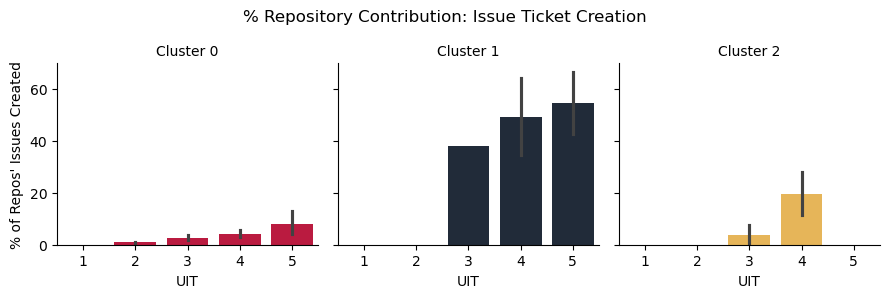

In [32]:
# Issue creatoin
# how are the users distributed across clusters: what size are the clusters? 
g = sns.FacetGrid(data=analysis_dataset, sharey=True, col="cluster_labels",)
g.map_dataframe(sns.barplot,
    x="breadth_interactions", 
    y="pc_issue_created",
    hue="cluster_labels", 
    #binwidth=1,
    #stat="count", 
    palette=label_color_dict, 
)
g.set_axis_labels("")
g.set_titles("Cluster {col_name}")
g.figure.subplots_adjust(top=0.80)
g.figure.suptitle("% Repository Contribution: Issue Ticket Creation")
g.set_xlabels("UIT")
g.set_ylabels("% of Repos' Issues Created")
#g.set_xlabels("Percentage Contribution Depth (% of repo commits)")
#plt.legend(title="Clusters", loc='upper right', labels=[f"{cl0}%", f"{cl1}%", f"{cl2}%"])
plt.savefig(f"../../images/RC-issue_creation_UIT_distribution_{current_date_info}.png") 
plt.show(g)

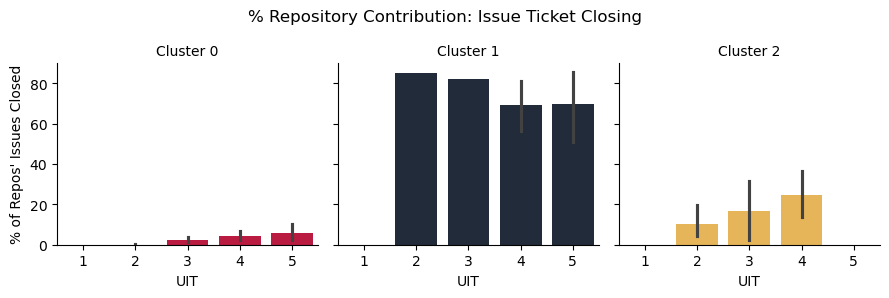

In [31]:
# Issue closure
# how are the users distributed across clusters: what size are the clusters? 
g = sns.FacetGrid(data=analysis_dataset, sharey=True, col="cluster_labels",)
g.map_dataframe(sns.barplot,
    x="breadth_interactions", 
    y="pc_issue_closed",
    hue="cluster_labels", 
    #binwidth=1,
    #stat="count", 
    palette=label_color_dict, 
)
g.set_axis_labels("")
g.set_titles("Cluster {col_name}")
g.figure.subplots_adjust(top=0.80)
g.figure.suptitle("% Repository Contribution: Issue Ticket Closing")
g.set_xlabels("UIT")
g.set_ylabels("% of Repos' Issues Closed")
#g.set_xlabels("Percentage Contribution Depth (% of repo commits)")
#plt.legend(title="Clusters", loc='upper right', labels=[f"{cl0}%", f"{cl1}%", f"{cl2}%"])
plt.savefig(f"../../images/RC-issue_closure_UIT_distribution_{current_date_info}.png") 
plt.show(g)

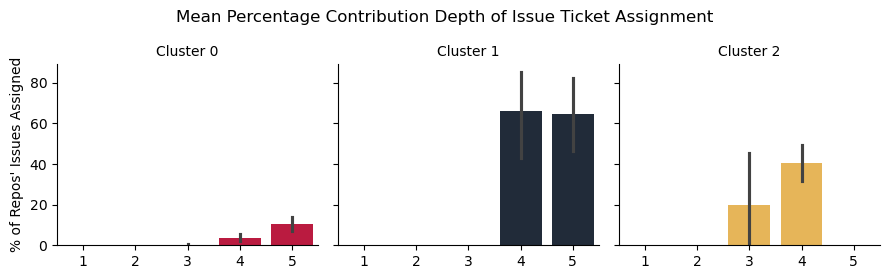

In [197]:
# Issue assignment
# how are the users distributed across clusters: what size are the clusters? 
g = sns.FacetGrid(data=analysis_dataset, sharey=True, col="cluster_labels",)
g.map_dataframe(sns.barplot,
    x="breadth_interactions", 
    y="pc_issues_assigned_of_assigned",
    hue="cluster_labels", 
    #binwidth=1,
    #stat="count", 
    palette=label_color_dict, 
)
g.set_axis_labels("")
g.set_titles("Cluster {col_name}")
g.figure.subplots_adjust(top=0.80)
g.figure.suptitle("Mean Percentage Contribution Depth of Issue Ticket Assignment")
g.set_ylabels("% of Repos' Issues Assigned")
#g.set_xlabels("Percentage Contribution Depth (% of repo commits)")
#plt.legend(title="Clusters", loc='upper right', labels=[f"{cl0}%", f"{cl1}%", f"{cl2}%"])
plt.savefig(f"../../images/breadth_depth_pc_issue_assignment_distribution_{current_date_info}.png") 
plt.show(g)

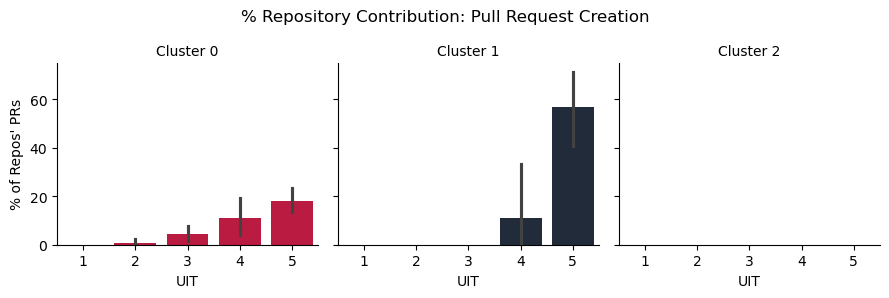

In [30]:
# PRs
# how are the users distributed across clusters: what size are the clusters? 
g = sns.FacetGrid(data=analysis_dataset, sharey=True, col="cluster_labels",)
g.map_dataframe(sns.barplot,
    x="breadth_interactions", 
    y="pc_pull_request_created",
    hue="cluster_labels", 
    #binwidth=1,
    #stat="count", 
    palette=label_color_dict, 
)
g.set_axis_labels("")
g.set_titles("Cluster {col_name}")
g.figure.subplots_adjust(top=0.80)
g.figure.suptitle("% Repository Contribution: Pull Request Creation")
g.set_xlabels("UIT")
g.set_ylabels("% of Repos' PRs")
#g.set_xlabels("Percentage Contribution Depth (% of repo commits)")
#plt.legend(title="Clusters", loc='upper right', labels=[f"{cl0}%", f"{cl1}%", f"{cl2}%"])
plt.savefig(f"../../images/RC-PRs_UIT_distribution_{current_date_info}.png") 
plt.show(g)

In [182]:
analysis_dataset.groupby("cluster_labels")["pc_pull_request_created"].mean()

cluster_labels
0     1.522720
1    27.623457
2     0.000000
Name: pc_pull_request_created, dtype: float64

In [124]:
# g = sns.FacetGrid(df_melted, row='column')
# g.map(plt.hist, 'value')

In [163]:
analysis_dataset.groupby("cluster_labels")["pc_DC"].mean()

cluster_labels
0     1.048095
1    54.404143
2    10.867988
Name: pc_DC, dtype: float64

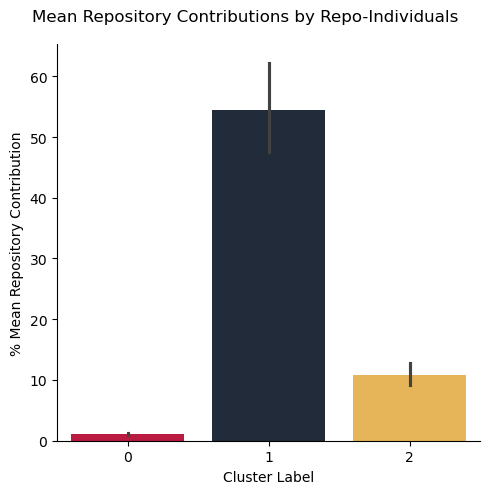

In [166]:
# pc_DC (percentage DEPTH of contribution across all of users' interactions)

g = sns.catplot(
    data=analysis_dataset, 
    x="cluster_labels", 
    y="pc_DC",
    hue="cluster_labels", 
    kind="bar", 
    estimator="mean",
    palette=label_color_dict, 
    legend = False,
)
#g.tick_params(axis='x', which='both', rotation=70)
#g.axes.legend().set_title("")
#g.add_legend(title="Clusters", loc='upper right',) #labels=['0', '1', '2']))
g.fig.subplots_adjust(top=0.9) # adjust the Figure in rp
g.fig.suptitle("Mean Repository Contributions by Repo-Individuals")
g.axes[0,0].set_xlabel('Cluster Label')
g.axes[0,0].set_ylabel('% Mean Repository Contribution')
plt.tight_layout()
#.axes.set_le
#plt.legend(title="Clusters", loc='upper left',) #labels=['0', '1', '2'])
plt.savefig(f"../../images/mrc_cluster_{current_date_info}.png") 
plt.show(g)

# MRC ANOVA by Cluster

ANOVA for pc_DC / MRC: 

In [224]:
import numpy as np
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

variable = "pc_DC"
df = clustering_data_labelled

# One-Way ANOVA: 
anova = f_oneway(
    df.groupby("cluster_labels")[variable].get_group(0),
    df.groupby("cluster_labels")[variable].get_group(1),
    df.groupby("cluster_labels")[variable].get_group(2),
)
    
print(f"{anova}")


# perform Tukey's test
tukey = pairwise_tukeyhsd(endog=df[variable],
                          groups=df['cluster_labels'],
                          alpha=0.05)

#display results
print(tukey)

print(f"For {variable}, anova result p-value is {anova.pvalue}; groups are significantly different = {anova.pvalue < 0.05}")
print(f"For {variable}, Tukey HSD test result p-value is {tukey.pvalues}; groups are significantly different = {tukey.reject == True}")



F_onewayResult(statistic=1725.9195159354783, pvalue=1.1367852885913273e-288)
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper   reject
-----------------------------------------------------
     0      1   53.356   0.0  51.1409  55.5712   True
     0      2   9.8199   0.0   8.5626  11.0772   True
     1      2 -43.5362   0.0 -46.0355 -41.0368   True
-----------------------------------------------------
For pc_DC, anova result p-value is 1.1367852885913273e-288; groups are significantly different = True
For pc_DC, Tukey HSD test result p-value is [8.09352585e-14 8.09352585e-14 8.09352585e-14]; groups are significantly different = [ True  True  True]


In [225]:
import numpy as np
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

variable = "pc_commit_created"
df = clustering_data_labelled

# One-Way ANOVA: 
anova = f_oneway(
    df.groupby("cluster_labels")[variable].get_group(0),
    df.groupby("cluster_labels")[variable].get_group(1),
    df.groupby("cluster_labels")[variable].get_group(2),
)
    
print(f"{anova}")


# perform Tukey's test
tukey = pairwise_tukeyhsd(endog=df[variable],
                          groups=df['cluster_labels'],
                          alpha=0.05)

#display results
print(tukey)

print(f"For {variable}, anova result p-value is {anova.pvalue}; groups are significantly different = {anova.pvalue < 0.05}")
print(f"For {variable}, Tukey HSD test result p-value is {tukey.pvalues}; groups are significantly different = {tukey.reject == True}")


F_onewayResult(statistic=1208.5463931159545, pvalue=8.51394129887289e-241)
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper   reject
-----------------------------------------------------
     0      1  65.4116   0.0  61.4086  69.4145   True
     0      2  31.3216   0.0  29.0495  33.5936   True
     1      2   -34.09   0.0 -38.6063 -29.5736   True
-----------------------------------------------------
For pc_commit_created, anova result p-value is 8.51394129887289e-241; groups are significantly different = True
For pc_commit_created, Tukey HSD test result p-value is [8.09352585e-14 8.09352585e-14 8.09352585e-14]; groups are significantly different = [ True  True  True]


In [226]:
import numpy as np
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

variable = "pc_pull_request_created"
df = clustering_data_labelled

# One-Way ANOVA: 
anova = f_oneway(
    df.groupby("cluster_labels")[variable].get_group(0),
    df.groupby("cluster_labels")[variable].get_group(1),
    df.groupby("cluster_labels")[variable].get_group(2),
)
    
print(f"{anova}")


# perform Tukey's test
tukey = pairwise_tukeyhsd(endog=df[variable],
                          groups=df['cluster_labels'],
                          alpha=0.05)

#display results
print(tukey)

print(f"For {variable}, anova result p-value is {anova.pvalue}; groups are significantly different = {anova.pvalue < 0.05}")
print(f"For {variable}, Tukey HSD test result p-value is {tukey.pvalues}; groups are significantly different = {tukey.reject == True}")


F_onewayResult(statistic=56.87224292898891, pvalue=8.480716444311142e-24)
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
     0      1  26.1007    0.0   20.293  31.9085   True
     0      2  -1.5227 0.5239  -4.8192   1.7738  False
     1      2 -27.6235    0.0 -34.1762 -21.0708   True
------------------------------------------------------
For pc_pull_request_created, anova result p-value is 8.480716444311142e-24; groups are significantly different = True
For pc_pull_request_created, Tukey HSD test result p-value is [8.09352585e-14 5.23871864e-01 8.09352585e-14]; groups are significantly different = [ True False  True]


In [329]:
analysis_dataset.columns

Index(['cluster_labels', 'repo_name', 'author_username',
       'n_of_commit_creators', 'n_changes', 'mean_n_changes',
       'median_n_changes_changed', 'std_n_changes_changed', 'n_files_changed',
       'mean_n_files', 'median_n_files_changed', 'std_n_files_changed',
       'hattori_lanza_size_cat_tiny', 'hattori_lanza_size_cat_small',
       'hattori_lanza_size_cat_medium', 'hattori_lanza_size_cat_large',
       'hattori_lanza_content_cat_forward_engineering',
       'hattori_lanza_content_cat_reengineering',
       'hattori_lanza_content_cat_corrective_engineering',
       'hattori_lanza_content_cat_management',
       'hattori_lanza_content_cat_empty_message',
       'hattori_lanza_content_cat_no_categorisation', 'vasilescu_category_doc',
       'vasilescu_category_img', 'vasilescu_category_l10n',
       'vasilescu_category_ui', 'vasilescu_category_media',
       'vasilescu_category_code', 'vasilescu_category_meta',
       'vasilescu_category_config', 'vasilescu_category_build',
 

In [332]:
import numpy as np
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

variable = "pc_V-doc"
df = analysis_dataset

# One-Way ANOVA: 
anova = f_oneway(
    df.groupby("cluster_labels")[variable].get_group(0),
    df.groupby("cluster_labels")[variable].get_group(1),
    df.groupby("cluster_labels")[variable].get_group(2),
)
    
print(f"{anova}")


# perform Tukey's test
tukey = pairwise_tukeyhsd(endog=df[variable],
                          groups=df['cluster_labels'],
                          alpha=0.05)

#display results
print(tukey)

print(f"For {variable}, anova result p-value is {anova.pvalue}; groups are significantly different = {anova.pvalue < 0.05}")
print(f"For {variable}, Tukey HSD test result p-value is {tukey.pvalues}; groups are significantly different = {tukey.reject == True}")


F_onewayResult(statistic=0.22395877182819676, pvalue=0.7993989515522767)
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     0      1  -0.7249 0.9956 -19.8566 18.4067  False
     0      2  -3.0826  0.783 -13.9418  7.7766  False
     1      2  -2.3576 0.9644 -23.9433 19.2281  False
-----------------------------------------------------
For pc_V-doc, anova result p-value is 0.7993989515522767; groups are significantly different = False
For pc_V-doc, Tukey HSD test result p-value is [0.99564482 0.78297883 0.96439251]; groups are significantly different = [False False False]


In [326]:
variable = "pc_DC"
df = clustering_data_labelled

# One-Way ANOVA: 
anova = f_oneway(
    df.groupby("breadth_interactions")[variable].get_group(1),
    df.groupby("breadth_interactions")[variable].get_group(2),
    df.groupby("breadth_interactions")[variable].get_group(3),
    df.groupby("breadth_interactions")[variable].get_group(4),
    df.groupby("breadth_interactions")[variable].get_group(5),
)
    
print(f"{anova}")


# perform Tukey's test
tukey = pairwise_tukeyhsd(endog=df[variable],
                          groups=df['breadth_interactions'],
                          alpha=0.05)

#display results
print(tukey)

print(f"For {variable}, anova result p-value is {anova.pvalue}; groups are significantly different = {anova.pvalue < 0.05}")
print(f"For {variable}, Tukey HSD test result p-value is {tukey.pvalues}; groups are significantly different = {tukey.reject == True}")


F_onewayResult(statistic=116.95128295443322, pvalue=2.923027552341426e-78)
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     1      2  -0.0757    1.0 -1.9682  1.8168  False
     1      3   2.6006 0.0178  0.2967  4.9045   True
     1      4  14.0067    0.0 11.2859 16.7274   True
     1      5  29.3784    0.0 24.6073 34.1494   True
     2      3   2.6763 0.0523 -0.0164   5.369  False
     2      4  14.0824    0.0 11.0254 17.1394   True
     2      5  29.4541    0.0 24.4836 34.4246   True
     3      4  11.4061    0.0  8.0787 14.7335   True
     3      5  26.7778    0.0 21.6366  31.919   True
     4      5  15.3717    0.0 10.0307 20.7127   True
----------------------------------------------------
For pc_DC, anova result p-value is 2.923027552341426e-78; groups are significantly different = True
For pc_DC, Tukey HSD test result p-value is [9.99967660e-01 1.78437090e-02 0.000000

In [ ]:
analysis_dataset.groupby("cluster_labels")

In [194]:
f, p = f_oneway(
    df.groupby("cluster_labels")[variable].get_group(0),
    df.groupby("cluster_labels")[variable].get_group(1),
    df.groupby("cluster_labels")[variable].get_group(2),
)
f

1725.9195159354783

In [193]:
p

1.1367852885913273e-288

In [107]:
#analysis_dataset.groupby("cluster_labels")[["pc_DC"]].mean().values[0])
# cl0_pcDC_mean = round(analysis_dataset.groupby("cluster_labels")[["pc_DC"]].mean().values[0], 2)
# cl1_pcDC_mean = round(analysis_dataset.groupby("cluster_labels")[["pc_DC"]].mean().values[1], 2)
# cl2_pcDC_mean = round(analysis_dataset.groupby("cluster_labels")[["pc_DC"]].mean().values[2], 2)

array([1.0480952])

## BREADTH X DEPTH X CLUSTER 

In [170]:
analysis_dataset.groupby("breadth_interactions")["pc_DC"].mean()

breadth_interactions
1     0.988105
2     0.912388
3     3.588693
4    14.994769
5    30.366467
Name: pc_DC, dtype: float64

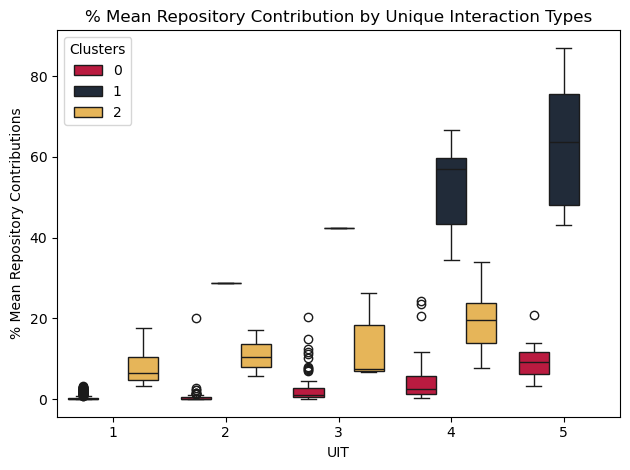

In [173]:
label_color_dict = {0:'#D50032', 1:'#1D2A3D', 2:'#FDBC42'} # universityred, epccnavy, dandelion, 
g = sns.boxplot(data=analysis_dataset,
    x="breadth_interactions", 
    y="pc_DC",
    hue="cluster_labels", 
    palette = label_color_dict)
g.set_title("% Mean Repository Contribution by Unique Interaction Types")
g.set_xlabel("UIT")
g.set_ylabel("% Mean Repository Contributions")
plt.legend(title="Clusters", loc='upper left',)# labels=[0,1,2])
plt.tight_layout()
plt.savefig(f"../../images/uit_mrc_cluster_{current_date_info}.png") 
plt.show(g)


#analysis_dataset.groupby(["breadth_interactions", "cluster_labels"])[["pc_DC"]].mean()

## (TIME)

In [ ]:
clustering_dataset

## Dendrogram

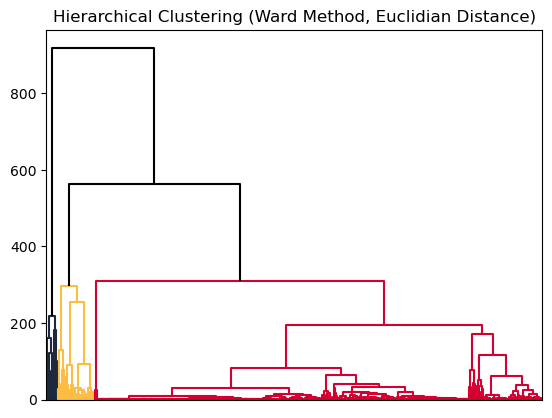

In [191]:
# THIS IS THE SCIPY HIERARCHICAL CLUSTERING METHODS
label_color_dict = ['#D50032', '#1D2A3D','#FDBC42'] # REVERESED COLOUR ORDER AS I'VE SET DISTANCE_SORT to TRUE!!!
sns.set_palette(label_color_dict)
from scipy.cluster.hierarchy import linkage, dendrogram

ward_clustering = linkage(clustering_dataset, method="ward", metric="euclidean")  

dendrogram(ward_clustering, show_contracted=True, no_labels=True, color_threshold = 400, above_threshold_color='black', count_sort=False, distance_sort=False)
plt.title("Hierarchical Clustering (Ward Method, Euclidian Distance)")
plt.savefig(f"../../images/dendrogram_ward_euclidian_x45repos_x{len(clustering_dataset)}project_individuals_{current_date_info}.png")
plt.show()
# 757.6017868314573 3 clusters CH score 18 Feb 2025

In [ ]:
clustering_dataset

## PCA 

In [10]:

from sklearn.decomposition import PCA
from sklearn.metrics import calinski_harabasz_score

model = AgglomerativeClustering(n_clusters = 3, metric = 'euclidean', linkage ='ward')
X = clustering_dataset
# Lets try to fit the hierarchical clustering algorithm  to dataset 
model_predictions = model.fit_predict(X)
cluster_labels = model_predictions

print(calinski_harabasz_score(X, cluster_labels))

clustering_data_labelled = pd.concat([pd.DataFrame({"cluster_labels":cluster_labels}), clustering_dataset], axis=1)

757.6017868314573


Explained variability per principal component: [0.71664387 0.14679582]


<Figure size 640x480 with 0 Axes>

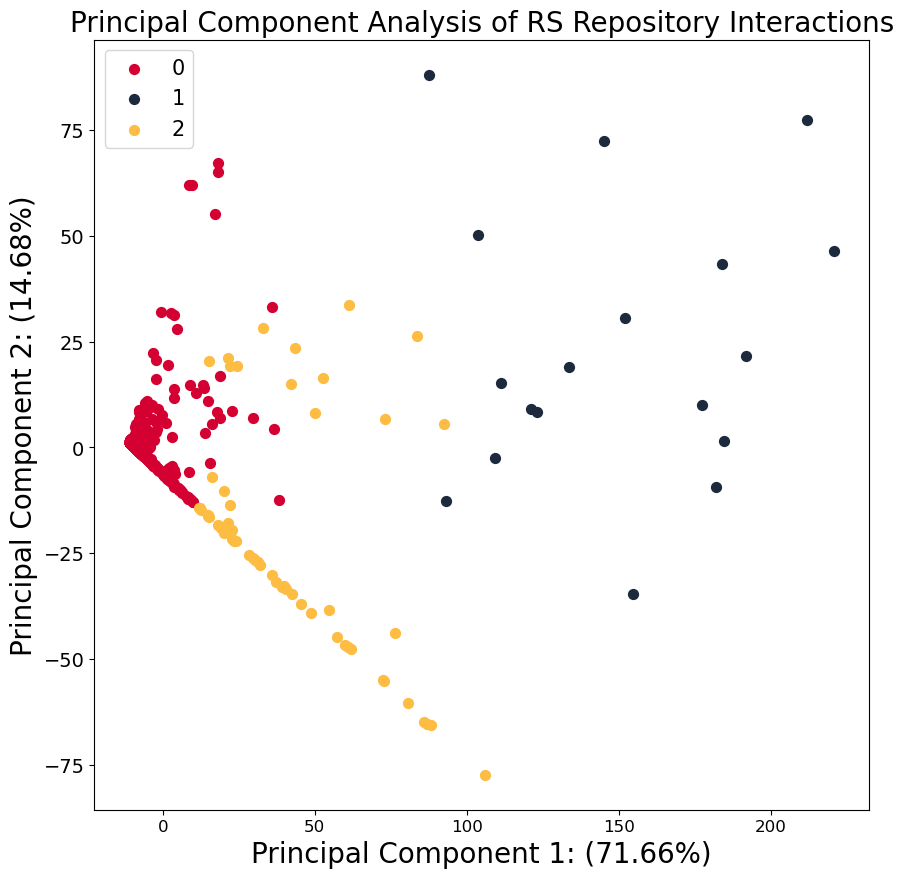

In [11]:
PCA_2 = PCA(n_components=2)
PCA_2_df = pd.DataFrame(data = PCA_2.fit_transform(clustering_dataset)
             , columns = ['principal component 1', 'principal component 2']) #  [0.69876736 0.16843182]

print('Explained variability per principal component: {}'.format(PCA_2.explained_variance_ratio_))

eigenvec1 = (PCA_2.explained_variance_ratio_)[0]*100
eigenvec2 = (PCA_2.explained_variance_ratio_)[1]*100

plt.figure()
plt.figure(figsize=(10,10))
plt.xticks(fontsize=12)
plt.yticks(fontsize=14)
plt.xlabel(f'Principal Component 1: ({round(eigenvec1, 2)}%)',fontsize=20)
plt.ylabel(f'Principal Component 2: ({round(eigenvec2, 2)}%)',fontsize=20)
plt.title("Principal Component Analysis of RS Repository Interactions",fontsize=20)
targets = [0,1,2]
#label_color_dict = {0:'#D50032', 1:'#1D2A3D', 2:'#FDBC42'}
colors = ['#D50032','#1D2A3D','#FDBC42'] ##,}# 2:'#FDBC42'} # universityred, epccnavy, dandelion,
for target, color in zip(targets,colors):
    indicesToKeep = clustering_data_labelled['cluster_labels'] == target
    plt.scatter(PCA_2_df.loc[indicesToKeep, 'principal component 1']
               , PCA_2_df.loc[indicesToKeep, 'principal component 2'], c = color, s = 50)

plt.legend(targets,prop={'size': 15})

PCA_2 = PCA(n_components=2)
PCA_2_df = pd.DataFrame(data = PCA_2.fit_transform(clustering_data_labelled)
             , columns = ['principal component 1', 'principal component 2'])
plt.savefig(f"../../images/PCA_2D_x{len(clustering_dataset)}project_individuals_{current_date_info}.png")
plt.show()

In [16]:
PCA_3 = PCA(n_components=3)
PCA_3_df = pd.DataFrame(data = PCA_3.fit_transform(clustering_dataset) # [0.71664387 0.14679582 0.08569358]
             , columns = ['principal component 1', 'principal component 2',  'principal component 3'])

print('Explained variability per principal component: {}'.format(PCA_3.explained_variance_ratio_))

Explained variability per principal component: [0.71664387 0.14679582 0.08569358]


In [17]:
PCA_feature_importance = pd.DataFrame(PCA_3.components_, columns = PCA_3.feature_names_in_, index=["PCA_1", "PCA_2", "PCA_3"])
PCA_feature_importance['PCA'] = PCA_feature_importance.index
PCA_feature_importance = PCA_feature_importance.reset_index(drop=True)
PCA_feature_importance

PCA_variables_reshape = pd.melt(PCA_feature_importance, id_vars = ["PCA"], value_vars=['breadth_interactions', 'pc_commit_created', 'pc_issue_created',
       'pc_issue_closed', 'pc_issues_assigned_of_assigned',  'pc_pull_request_created', 'pc_DC', 'pc_sum_n_interactions',
       'pc_interaction_days', 'interaction_days', 'interaction_period_days', 'pc_created-closed_issues', 'sum_n_interactions', 'mean_n_interactions_per_interaction_day',
       'interactions_by_user_encoded'], var_name = "variable_involved", value_name = "PCA_importance_value")
PCA_variables_reshape.sort_values(by=["PCA", "PCA_importance_value"], ascending=[True, False])

# PCA1: pc_commit_created (0.51), pc_sum_n_interactions (0.50), pc_interaction_days (0.42)
# PCA2: pc_assigned (0.46), pc_issue_closed (0.44), pc_pull_request_created (0.35) 
# PCA3: pc_pull_request_created (0.90), pc_interaction_days (0.1), interactions_by_user (0.1)

# PCA3 is the axis which spreads the yellow group on a continuum, and it's mostly pc_PRs based, so probably not super crucial!


,PCA,variable_involved,PCA_importance_value
3,PCA_1,pc_commit_created,0.474492
21,PCA_1,pc_sum_n_interactions,0.464141
24,PCA_1,pc_interaction_days,0.389121
9,PCA_1,pc_issue_closed,0.361960
12,PCA_1,pc_issues_assigned_of_assigned,0.321070
18,PCA_1,pc_DC,0.306320
6,PCA_1,pc_issue_created,0.242619
15,PCA_1,pc_pull_request_created,0.131461
42,PCA_1,interactions_by_user_encoded,0.028722
27,PCA_1,interaction_days,0.027435


# Percentage of user's commits which categorised as HL commit content category MANAGEMENT by cluster


,pc_HL-mgmt
cluster_labels,
0,18.839851
1,26.324040
2,25.979452


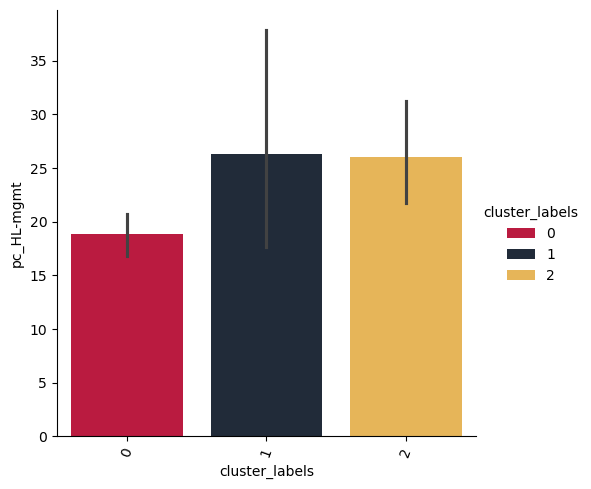

In [18]:
# Percentage of user's commits which categorised as HL commit content category MANAGEMENT
label_color_dict = {0:'#D50032', 1:'#1D2A3D', 2:'#FDBC42'} # universityred, epccnavy, dandelion, 
g = sns.catplot(
    data=analysis_dataset, 
    x="cluster_labels", 
    y="pc_HL-mgmt",
    hue="cluster_labels", 
    kind="bar", 
    estimator="mean",
    palette=label_color_dict,
)
g.tick_params(axis='x', which='both', rotation=70)
print("# Percentage of user's commits which categorised as HL commit content category MANAGEMENT by cluster")
analysis_dataset.groupby("cluster_labels")[["pc_HL-mgmt"]].mean()

# Percentage of user's commits which categorised as V-cat Docs by cluster


,pc_V-doc
cluster_labels,
0,27.562900
1,26.837955
2,24.480348


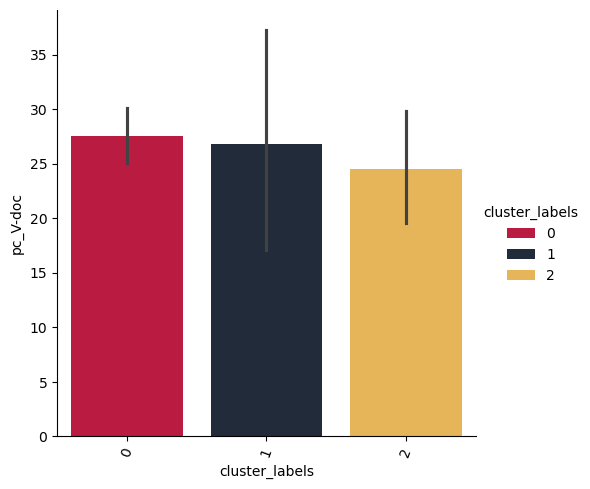

In [19]:

label_color_dict = {0:'#D50032', 1:'#1D2A3D', 2:'#FDBC42'} # universityred, epccnavy, dandelion, 
g = sns.catplot(
    data=analysis_dataset, 
    x="cluster_labels", 
    y="pc_V-doc",
    hue="cluster_labels", 
    kind="bar", 
    estimator="mean",
    palette=label_color_dict,
)
g.tick_params(axis='x', which='both', rotation=70)
print("# Percentage of user's commits which categorised as V-cat Docs by cluster")
analysis_dataset.groupby("cluster_labels")[["pc_V-doc"]].mean()

In [ ]:
# pairplots 
# # import seaborn as sns

# # print(clustering_data_labelled.keys())
# label_color_dict = {0:'#D50032', 1:'#1D2A3D', 2:'#FDBC42'} # universityred, epccnavy, dandelion, 

# print(clustering_data_labelled.keys())

# # Rename classes using the iris target names
# clustering_data_labelled["target"] = clustering_data_labelled.cluster_labels # create column called 'target' that's the same as cluster_labels :s
# _ = sns.pairplot(clustering_data_labelled, hue="cluster_labels", palette=label_color_dict)